# Анализ пассажиров Титаника
Учебный pet-проект по анализу данных списка пассажиров Титаника.

Data-set взят с https://www.kaggle.com/competitions/titanic/data?select=train.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/train.csv")

## Форма и структура

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


| Поле | Тип | Описание |
|------|-----|----------|
| PassengerId | int | Уникальный идентификатор пассажира |
| Survived | int | Выжил (1) или нет (0) |
| Pclass | int | Класс билета: 1 (первый), 2 (второй), 3 (третий) |
| Name | str | Имя пассажира |
| Sex | str | Пол: male / female |
| Age | float | Возраст в годах |
| SibSp | int | Количество братьев, сестёр и супругов на борту |
| Parch | int | Количество родителей и детей на борту |
| Ticket | str | Номер билета |
| Fare | float | Стоимость билета в фунтах |
| Cabin | str | Номер каюты |
| Embarked | str | Порт посадки: C (Шербур), Q (Квинстаун), S (Саутгемптон) |

```Age``` имеет ~20% пропусков – в анализе используются только строки с известным возрастом.

```Cabin``` имеет ~77% пропусков – поле не используется в анализе

## Первый/последний взгляд

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


## Пропуски

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Статистика

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Выживаемость по полу
__Гипотеза__: Женщины выживали чаще мужчин.

In [7]:
sex_survival = (df.groupby("Sex", as_index=False)
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.loc[:, ["Sex", "Survived_percent"]]
	.sort_values("Survived_percent", ascending=False)
)
print(sex_survival)

      Sex  Survived_percent
0  female             74.20
1    male             18.89


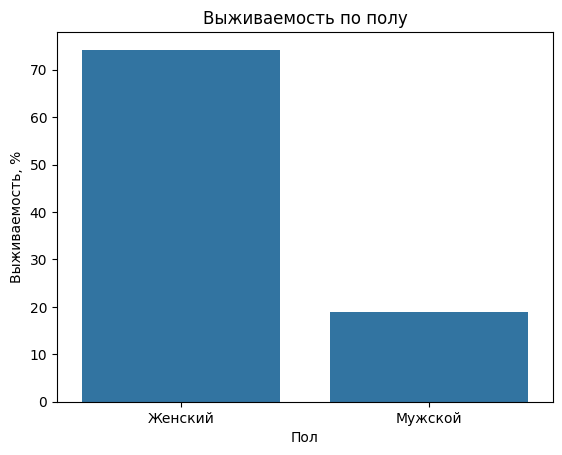

In [36]:
sex_survival_schedule = sns.barplot(
	data=sex_survival,
	x="Sex",
	y="Survived_percent"
)

xlabels = {
	"male": "Мужской", 
	"female": "Женский"
}

sex_survival_schedule.set_xticks(sex_survival_schedule.get_xticks())
sex_survival_schedule.set_xticklabels(
	xlabels.get(tlabel.get_text(), tlabel.get_text())
	for tlabel in sex_survival_schedule.get_xticklabels()
)

plt.title("Выживаемость по полу")
plt.xlabel("Пол")
plt.ylabel("Выживаемость, %")

plt.savefig("../images/sex_survival.png", dpi=150, bbox_inches="tight")
plt.show()

__Гипотеза ПОДТВЕРДИЛАСЬ__.

```74.20%``` - выживаемость женщин.

```18.89%``` - выживаемость мужчин.

Это может быть обусловлено порядком эвакуации, а именно правилом _"Сначала женщины и дети"_.

## Выживаемость по классу билета
__Гипотеза__: чем ниже класс билета, тем ниже выживаемость.

In [9]:
pclass_survival = (df.groupby("Pclass", as_index=False)
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.loc[:, ["Pclass", "Survived_percent"]]
	.sort_values("Survived_percent", ascending=False)
)
print(pclass_survival)

   Pclass  Survived_percent
0       1             62.96
1       2             47.28
2       3             24.24


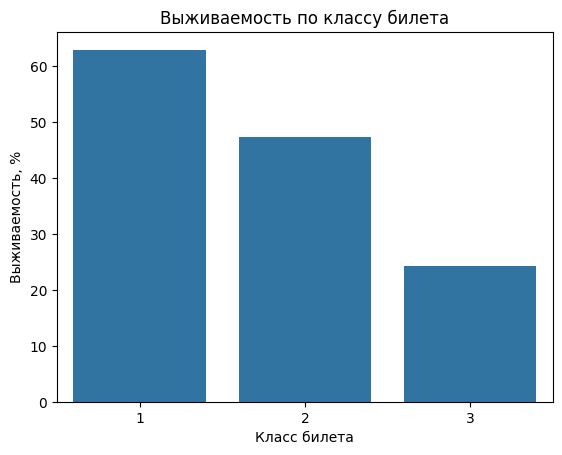

In [ ]:
sns.barplot(
	data=pclass_survival,
	x="Pclass",
	y="Survived_percent"
)

plt.title("Выживаемость по классу билета")
plt.xlabel("Класс билета")
plt.ylabel("Выживаемость, %")

plt.savefig("../images/pclass_survival.png", dpi=150, bbox_inches="tight")
plt.show()

__Гипотеза ПОДТВЕРДИЛАСЬ__.

Выживаемость пассажиров по классам билетов:

- ```62.96%``` - 1 (первый);

- ```47.28%``` - 2 (второй);

- ```24.24%``` - 3 (третий).

Вероятно это объясняется тем, что шлюпки располагались на верхних палубах, доступных преимущественно пассажирам первого класса. Также это может быть предположительно связано с тем, что пассажиров первого класса первыми уведомили о начале эвакуации, а пассажиров третьего класса до последнего пытались не пустить на верхние палубы.

## Выживаемость по возрасту
__Гипотеза__: дети и подростки выживали чаще. Пожилые погибали чаще всего.

In [11]:
age_bins = [0, 12, 17, 60, 80]
age_labels = ["Дети", "Подростки", "Взрослые", "Пожилые"]

age_group_survival = (df.assign(
	Age_group=lambda x: pd.cut(x["Age"],
		bins=age_bins,
		labels=age_labels
	))
	.groupby("Age_group", as_index=False)
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.loc[:, ["Age_group", "Survived_percent"]]
	.sort_values("Survived_percent", ascending=False)
)
print(age_group_survival)

   Age_group  Survived_percent
0       Дети             57.97
1  Подростки             47.73
2   Взрослые             38.69
3    Пожилые             22.73


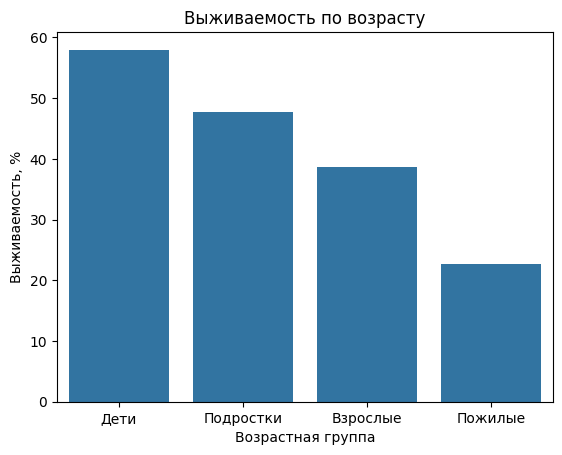

In [38]:
sns.barplot(
	data=age_group_survival,
	x="Age_group",
	y="Survived_percent"
)

plt.title("Выживаемость по возрасту")
plt.xlabel("Возрастная группа")
plt.ylabel("Выживаемость, %")

plt.savefig("../images/age_group_survival.png", dpi=150, bbox_inches="tight")
plt.show()

__Гипотеза ПОДТВЕРДИЛАСЬ__.

Выживаемость по возрастным группам:

- ```57.97%``` - дети;

- ```47.73%``` - подростки;

- ```38.69%``` - взрослые;

- ```22.73%``` - пожилые.

Это может быть обусловлено порядком эвакуации, а именно правилом _"Сначала женщины и дети"_. Пожилые погибали чаще всего предположительно ввиду слабых физических данных, поскольку катастрофа развивалась стремительно и требовала серьёзной физической активности.

## Зависимость возраста и класса билета
__Гипотеза__: чем больше возраст пассажира, тем выше класс его билета.

### Распределение классов внутри возрастных групп

In [13]:
age_bins = [0, 12, 17, 60, 80]
age_labels = ["дети", "подростки", "взрослые", "пожилые"]

pclass_by_age_group = (df.assign(Age_group=lambda x: pd.cut(x["Age"],
		bins=age_bins,
		labels=age_labels
	))
	.groupby(["Age_group", "Pclass"])
	.agg(Pclass_count=("Pclass", "size"))
	.assign(Pclass_percent=lambda x: round(
		x["Pclass_count"] / 
		x.groupby("Age_group")["Pclass_count"].transform("sum") * 100, 2
	))
	.sort_values(["Age_group", "Pclass"])
)
print(pclass_by_age_group)

                  Pclass_count  Pclass_percent
Age_group Pclass                              
дети      1                  4            5.80
          2                 17           24.64
          3                 48           69.57
подростки 1                  8           18.18
          2                  6           13.64
          3                 30           68.18
взрослые  1                160           27.63
          2                147           25.39
          3                272           46.98
пожилые   1                 14           63.64
          2                  3           13.64
          3                  5           22.73


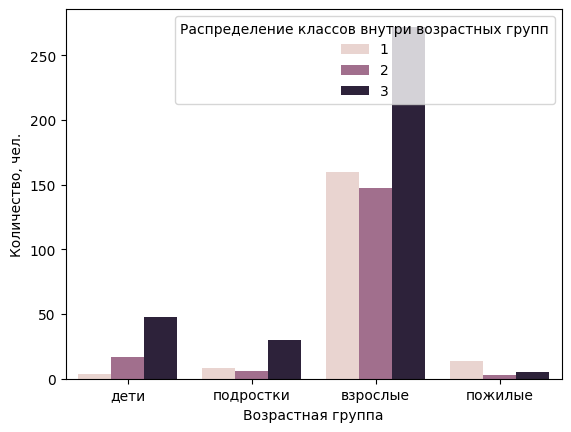

In [14]:
sns.barplot(
	data=pclass_by_age_group,
	x="Age_group",
	y="Pclass_count",
	hue="Pclass"
)

plt.legend(title="Распределение классов внутри возрастных групп")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество, чел.")
plt.show()

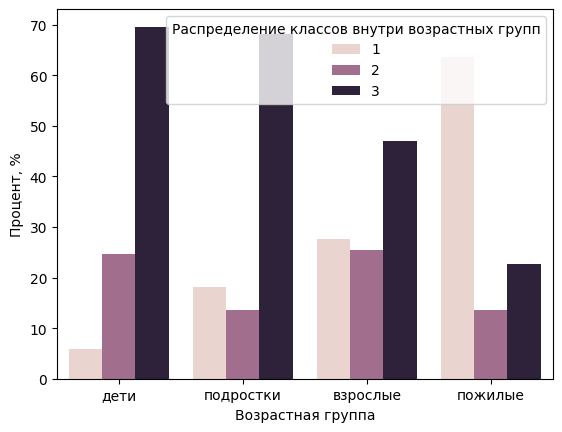

In [15]:
sns.barplot(
	data=pclass_by_age_group,
	x="Age_group",
	y="Pclass_percent",
	hue="Pclass"
)

plt.legend(title="Распределение классов внутри возрастных групп")
plt.xlabel("Возрастная группа")
plt.ylabel("Процент, %")
plt.show()

### Средний возраст по классу

In [16]:
(df.groupby("Pclass", as_index=False)
	.agg(Mean_age=("Age", lambda x: round(x.mean(), 1)))
	.sort_values("Pclass")
)

,Pclass,Mean_age
0,1,38.2
1,2,29.9
2,3,25.1


__Гипотеза ПОДТВЕРДИЛАСЬ__.

Если рассматривать распределение классов внутри возрастных групп, то можно выделить следующие показатели:

- ```69.57%``` - детей плыли третьим классом;

- ```68.18%``` - подростков плыли третьим классом;

- ```46.98%``` - взрослых плыли третьим классом;

- ```63.64%``` - пожилых плыли первым классом.

Также гипотеза подтвеждается средним возрастом по классу:

- ```38.2``` - 1 (первый);

- ```29.9``` - 2 (второй);

- ```25.1``` - 3 (третий).

Таким образом прямая корреляция возраста и класса билета может быть обусловлена тем, что пожилые успели накопить состояние, в то время как более молодые отправлялись в Америку на заработки.


## Выживаемость по размеру семьи
__Гипотеза__: одиночки выживали чаще, т.е. чем меньше размер семьи - тем выше выживаемость.

In [17]:
family_size_survival = (df.assign(Family_size=lambda x: x["SibSp"] + x["Parch"] + 1)
	.groupby("Family_size", as_index=False)
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.sort_values("Survived_percent", ascending=False)
)
print(family_size_survival)

   Family_size  Survived_percent
3            4             72.41
2            3             57.84
1            2             55.28
6            7             33.33
0            1             30.35
4            5             20.00
5            6             13.64
7            8              0.00
8           11              0.00


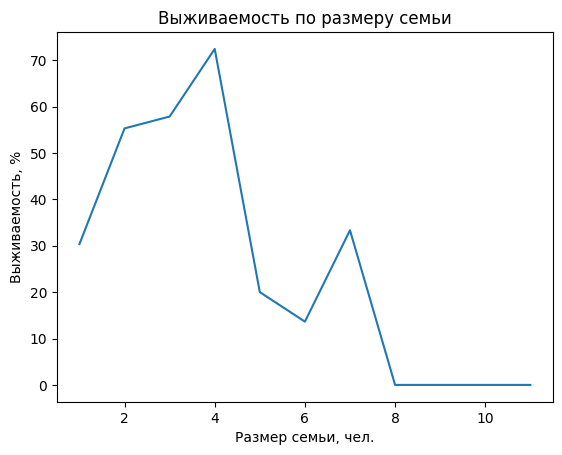

In [18]:
sns.lineplot(
	data=family_size_survival,
	x="Family_size",
	y="Survived_percent"
)

plt.title("Выживаемость по размеру семьи")
plt.xlabel("Размер семьи, чел.")
plt.ylabel("Выживаемость, %")
plt.show()

### Концентрация размеров семьи по классу билета

In [19]:
family_size_by_pclass = (df.assign(Family_size=lambda x: x["SibSp"] + x["Parch"] + 1)
	.groupby(["Pclass", "Family_size"])
	.agg(Family_size_count=("Family_size", "count"))
	.assign(Family_size_percent=lambda x: round(
		x["Family_size_count"] /
		x.groupby("Pclass")["Family_size_count"].transform("sum") * 100, 2
	))
	.sort_values(["Pclass", "Family_size_percent"], ascending=[True, False])
)
print(family_size_by_pclass)

                    Family_size_count  Family_size_percent
Pclass Family_size                                        
1      1                          109                50.46
       2                           70                32.41
       3                           24                11.11
       4                            7                 3.24
       6                            4                 1.85
       5                            2                 0.93
2      1                          104                56.52
       2                           34                18.48
       3                           31                16.85
       4                           13                 7.07
       5                            1                 0.54
       6                            1                 0.54
3      1                          324                65.99
       2                           57                11.61
       3                           47                 9.

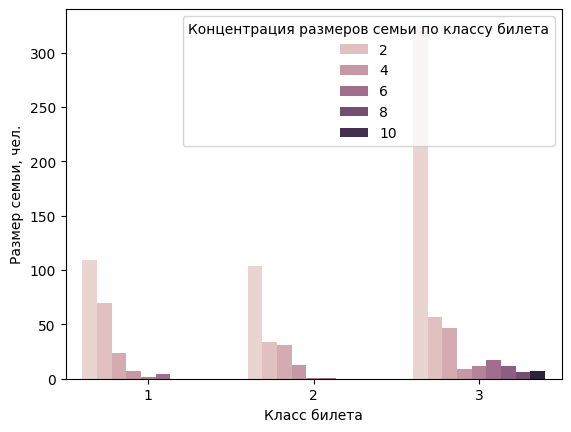

In [20]:
sns.barplot(
	data=family_size_by_pclass,
	x="Pclass",
	y="Family_size_count",
	hue="Family_size"
)

plt.legend(title="Концентрация размеров семьи по классу билета")
plt.xlabel("Класс билета")
plt.ylabel("Размер семьи, чел.")
plt.show()

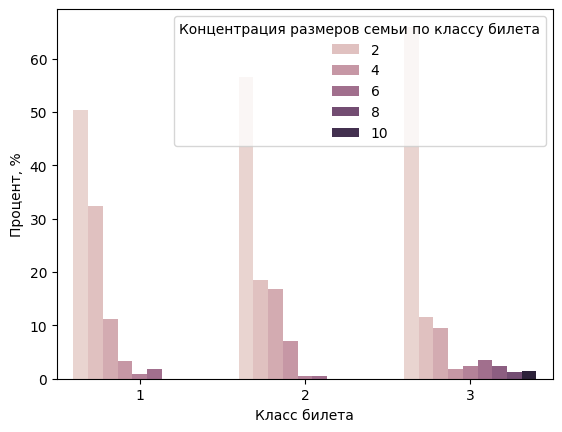

In [21]:
sns.barplot(
	data=family_size_by_pclass,
	x="Pclass",
	y="Family_size_percent",
	hue="Family_size"
)

plt.legend(title="Концентрация размеров семьи по классу билета")
plt.xlabel("Класс билета")
plt.ylabel("Процент, %")
plt.show()

__Гипотеза НЕ ПОДТВЕРДИЛАСЬ__.

Если рассматривать выживаемость по размеру семьи, то видно, что чаще всего выживали небольшие семьи размером от 2-4 человек. Однако одиночки выживали чаще больших семей. 

Это может быть обусловлено концентрацией размеров семьи по классу билета. Можно заметить, что маленькие семьи составляли большую долю в первом и втором классе. Исходя из того, что [выживаемость по классу билета](#выживаемость-по-классу-билета) показывает, что _чем выше класс билета, тем выше выживаемость_, можно утверждать, что высокий процент выживаемости маленьких семей относительно одиночек и более крупных семей обусловлен не размерностью, а более высокой концентрацией в классах с более высокой общей выживаемостью.

## Выживаемость по порту посадки
__Гипотеза__: пассажиры, севшие в Саутгемптоне , имели наименьший процент выживаемости.

In [22]:
embarked_survival = (df.groupby("Embarked")
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.sort_values("Survived_percent", ascending=False)
)
print(embarked_survival)

          Survived_percent
Embarked                  
C                    55.36
Q                    38.96
S                    33.70


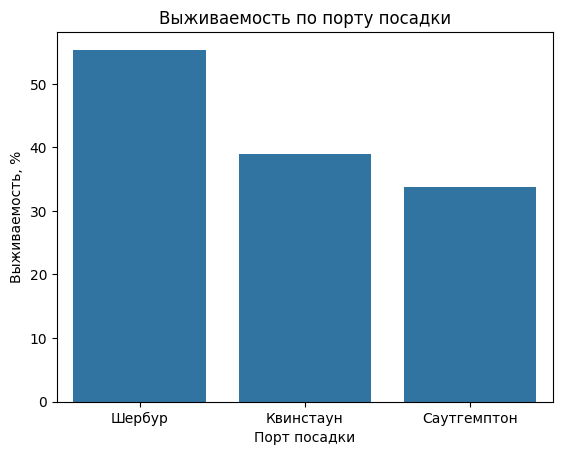

In [23]:
embarked_survival_schedule = sns.barplot(
	data=embarked_survival,
	x="Embarked",
	y="Survived_percent"
)

xlabels = {
	"C": "Шербур", 
	"Q": "Квинстаун",
	"S": "Саутгемптон"
}

embarked_survival_schedule.set_xticks(embarked_survival_schedule.get_xticks())
embarked_survival_schedule.set_xticklabels(
	xlabels.get(tlabel.get_text(), tlabel.get_text())
	for tlabel in embarked_survival_schedule.get_xticklabels()
)

plt.title("Выживаемость по порту посадки")
plt.xlabel("Порт посадки")
plt.ylabel("Выживаемость, %")
plt.show()

### Концентрация классов билетов по портам посадки

In [24]:
pclass_by_embarked = (df.groupby(["Embarked", "Pclass"])
	.agg(Pclass_count=("Pclass", "count"))
	.assign(Pclass_percent=lambda x: round(
		x["Pclass_count"] /
		x.groupby("Embarked")["Pclass_count"].transform("sum") * 100, 2
	))
	.sort_values(["Embarked", "Pclass_percent"], ascending=[True, False])
)
print(pclass_by_embarked)

                 Pclass_count  Pclass_percent
Embarked Pclass                              
C        1                 85           50.60
         3                 66           39.29
         2                 17           10.12
Q        3                 72           93.51
         2                  3            3.90
         1                  2            2.60
S        3                353           54.81
         2                164           25.47
         1                127           19.72


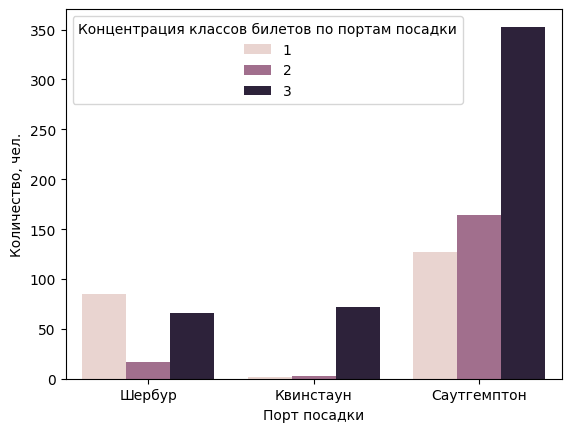

In [25]:
pclass_by_embarked_schedule = sns.barplot(
	data=pclass_by_embarked,
	x="Embarked",
	y="Pclass_count",
	hue="Pclass"
)

xlabels = {
	"C": "Шербур", 
	"Q": "Квинстаун",
	"S": "Саутгемптон"
}

pclass_by_embarked_schedule.set_xticks(pclass_by_embarked_schedule.get_xticks())
pclass_by_embarked_schedule.set_xticklabels(
	xlabels.get(tlabel.get_text(), tlabel.get_text())
	for tlabel in pclass_by_embarked_schedule.get_xticklabels()
)

plt.legend(title="Концентрация классов билетов по портам посадки")
plt.xlabel("Порт посадки")
plt.ylabel("Количество, чел.")
plt.show()

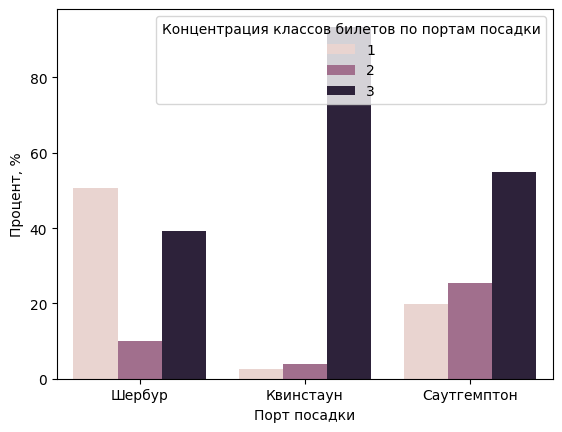

In [26]:
pclass_by_embarked_schedule = sns.barplot(
	data=pclass_by_embarked,
	x="Embarked",
	y="Pclass_percent",
	hue="Pclass"
)

xlabels = {
	"C": "Шербур", 
	"Q": "Квинстаун",
	"S": "Саутгемптон"
}

pclass_by_embarked_schedule.set_xticks(pclass_by_embarked_schedule.get_xticks())
pclass_by_embarked_schedule.set_xticklabels(
	xlabels.get(tlabel.get_text(), tlabel.get_text())
	for tlabel in pclass_by_embarked_schedule.get_xticklabels()
)

plt.legend(title="Концентрация классов билетов по портам посадки")
plt.xlabel("Порт посадки")
plt.ylabel("Процент, %")
plt.show()

__Гипотеза ПОДТВЕРДИЛАСЬ__.

Это может быть обусловлено тем, что большинство пассажиров, отправившихся из Саутгемптона - пассажиры третьего класса. А исходя из того, что [выживаемость по классу билета](#выживаемость-по-классу-билета) показывает, что _чем выше класс билета, тем выше выживаемость_, то низкий процент выживших из Саутгемптона закономерен. Это также подтвержается высоким процентов выживших из Шербура, где половина пассажиров - обладатели билетов первого класса.

Однако из общей картины выбивается Квинстаун. ```93.51%``` пассажиров - это обладатели билетов третьего класса. Однако общий процент выживших выше, чем в Саутгемптоне. Предполагаю, что это может быть связано с высокой долей женщин, отправившихся из Квинстауна:

In [27]:
(df.groupby(["Embarked", "Sex"])
	.agg(Sex_count=("Sex", "count"))
	.assign(Sex_percent=lambda x: round(
		x["Sex_count"] /
		x.groupby("Embarked")["Sex_count"].transform("sum") * 100, 2
	))
	.sort_values(["Embarked", "Sex_percent"], ascending=[True, False])
)

Sex_count  Sex_percent
Embarked Sex                           
C        male           95        56.55
         female         73        43.45
Q        male           41        53.25
         female         36        46.75
S        male          441        68.48
         female        203        31.52

Это не нашло подтверждения. Распределение по полу среди пассажиров из Квинстауна примерно равное. Вероятно аномалия Квинстауна связана с очень маленькой выборкой - ```77``` пассажиров.

## Сводный анализ выживаемости по полу, классу и возрасту

### Выживаемость мужчин по классу и возрасту

In [28]:
age_bins = [0, 12, 17, 60, 80]
age_labels = ["Дети", "Подростки", "Взрослые", "Пожилые"]

male_survival_by_pclass_age_group = (df.loc[df["Sex"] == "male"]
	.assign(Age_group=lambda x: pd.cut(x["Age"],
		bins=age_bins,
		labels=age_labels					
	))
	.groupby(["Pclass", "Age_group"])
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.sort_values(["Pclass", "Age_group"])
)
print(male_survival_by_pclass_age_group)

                  Survived_percent
Pclass Age_group                  
1      Дети                 100.00
       Подростки            100.00
       Взрослые              41.18
       Пожилые                8.33
2      Дети                 100.00
       Подростки              0.00
       Взрослые               5.88
       Пожилые               33.33
3      Дети                  36.00
       Подростки              5.56
       Взрослые              13.59
       Пожилые                0.00


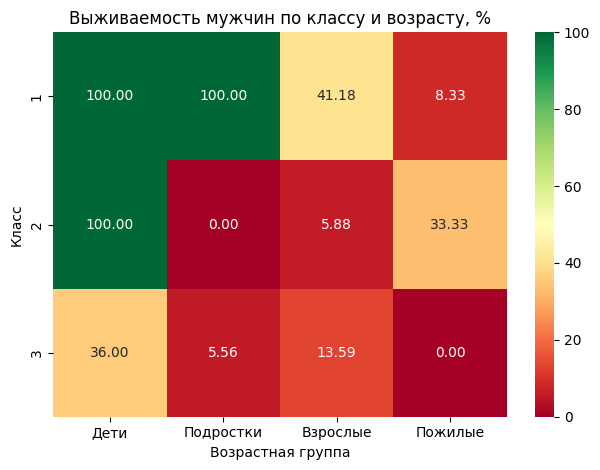

In [34]:
pivot = male_survival_by_pclass_age_group["Survived_percent"].unstack("Age_group")

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
)

plt.title("Выживаемость мужчин по классу и возрасту, %")
plt.xlabel("Возрастная группа")
plt.ylabel("Класс")
plt.tight_layout()

plt.savefig("../images/male_survival_by_pclass_age_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
age_bins = [0, 12, 17, 60, 80]
age_labels = ["Дети", "Подростки", "Взрослые", "Пожилые"]

female_survival_by_pclass_age_group = (df.loc[df["Sex"] == "female"]
	.assign(Age_group=lambda x: pd.cut(x["Age"],
		bins=age_bins,
		labels=age_labels					
	))
	.groupby(["Pclass", "Age_group"])
	.agg(Survived_percent=("Survived", lambda x: round(sum(x) / len(x) * 100, 2)))
	.sort_values(["Pclass", "Age_group"])
)
print(female_survival_by_pclass_age_group)

                  Survived_percent
Pclass Age_group                  
1      Дети                   0.00
       Подростки            100.00
       Взрослые              97.33
       Пожилые              100.00
2      Дети                 100.00
       Подростки            100.00
       Взрослые              90.32
3      Дети                  47.83
       Подростки             66.67
       Взрослые              40.91
       Пожилые              100.00


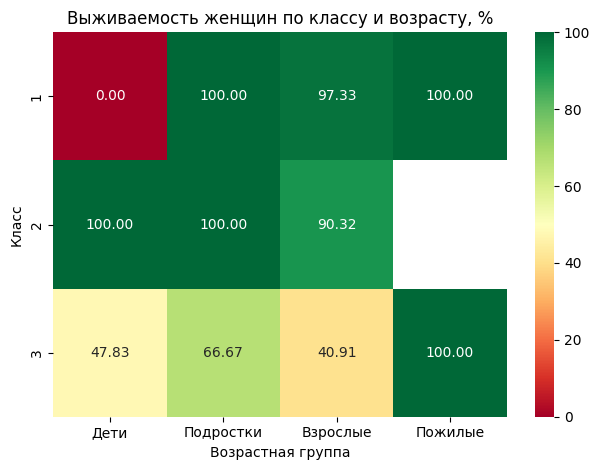

In [35]:
pivot = female_survival_by_pclass_age_group["Survived_percent"].unstack("Age_group")

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
)

plt.title("Выживаемость женщин по классу и возрасту, %")
plt.xlabel("Возрастная группа")
plt.ylabel("Класс")
plt.tight_layout()

plt.savefig("../images/female_survival_by_pclass_age_group.png", dpi=150, bbox_inches="tight")
plt.show()

__Выводы по сводному анализу__.

Рассматривая тепловые карты выживаемости мужчин и женщин по классу билета и возрастной группе можно однозначно утверждать, что женщины выживали намного чаще мужчин во всех категориях. 

Заметим, что принадлежность к полу не является единственным фактором выживания, что можно заметить по падению выживаемости относительно класса билета независимо от пола пассажира.

Если говорить о выживаемости по возрастной группе, то также можно заметить закономерность - чем младше пассажир, тем выше шанс его выживания.

Стоит также упомянуть об аномальных показателях выживаемости для следующих категорий пассажиров:
- подростки 2-го класса мужского пола;
- дети 1-го класса женского пола;
- пожилые 3-го класса женского пола.

Данные показатели скорее всего связаны с крайне небольшой выборкой (менее 10 человек в каждой из категорий).

# Общие выводы

В ходе данной аналитической работы основным объектом анализа рассматривалась выживаемость пассажиров "Титаника" относительно различных категорий: пол, класс билета, возрастная группа, размер семьи и порт посадки.

В ходе проверки результатов выдвинутых гипотез относительно выживаемости пассажиров по вышеописанным категориям, были обнаружены следующие закономерности:
- Класс билета является главным фактором, влияющим на выживаемость пассажира. Это подтверждается ростом выживаемости пассажира относительно класса билета вне зависимости от пола, возрастной группы и других категорий. Это может быть вызвано тем, что пассажиры 1-го класса были уведомлены о начале эвакуации раньше всех. Также на это могло повлиять размещение спасательных шлюпок преимущественно на верхних палубах парохода, которые занимали пассажиры 1-го и 2-го класса.
- Не менее важным фактором выживаемости является пол. Женщины выживали в разы чаще, чем мужчины. Это может быть обусловлено организацией эвакуации, а именно правилом _"Сначала женщины и дети"_.
- Также стоит отметить зависимость выживаемости от возрастной группы пассажира. Чем младше пассажир, тем выше его шансы на выживание. Это может быть так же связано с вышеописанным правилом о порядке эвакуации. 

При анализе влияния размера семьи на выживаемость пассажира было обнаружено, что высокий процент выживаемости пассажиров из малых семей (2-4 человека) обусловлен не размером семьи, а концентрацией данных семей преимущественно в 1-ом и 2-ом классе, где выживаемость наиболее высокая.

Порт отправления показал аналогичную зависимость. Например, максимальный процент выживаемости пассажиров, отправившихся из Шербура обусловлен высокой концентрацией пассажиров 1-го класса.